# CardioIA Fase 4 - Parte 2: CNN do Zero

**FIAP | Tecnologo em Inteligencia Artificial | Fase 4 | Capitulo 1 | Grupo 72**

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/juanvoltolini-rm562890/CardioIA-Fase4-Cap1/blob/main/notebooks/02_cnn_do_zero.ipynb)

Este notebook implementa a **CNN treinada do zero** da Parte 2 do enunciado, usando exatamente o mesmo split do NB01 (manifestos em `data/splits/`).

Fluxo: `tf.data` lendo os CSVs -> augmentation e normalizacao embutidas no modelo -> 4 blocos convolucionais -> avaliacao completa no **conjunto de teste** (matriz de confusao, precision/recall/F1, AUC-ROC) -> exportacao de `cnn_zero.keras`.

Decisoes (detalhadas em `docs/plano_de_trabalho.md`):
- Rotulo: **NORMAL = 0, PNEUMONIA = 1** (a saida sigmoid e a probabilidade de PNEUMONIA; o Flask usa threshold 0.5).
- Imagem **224x224x3** (mesmo tamanho do VGG16, para comparacao justa).
- Normalizacao `Rescaling(1/255)` **embutida no modelo** (evita esquecer a normalizacao na inferencia do Flask/mobile).
- Augmentation **sem flip horizontal** (espelhar o torax inverte a posicao do coracao).
- Desbalanceamento (~73% pneumonia) tratado com `class_weight`; avaliacao sempre por classe.

## 1. Configuracao do ambiente

Seed fixa (42) para reprodutibilidade. Registramos a versao do TensorFlow porque o `requirements.txt` do prototipo Flask deve pinar a mesma versao usada no treino.

In [1]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from PIL import Image

SEED = 42
keras.utils.set_random_seed(SEED)

IMG = 224          # lado da imagem (224x224)
BATCH = 32
EPOCHS = 30
AUTOTUNE = tf.data.AUTOTUNE
MAPA_ROTULO = {'NORMAL': 0, 'PNEUMONIA': 1}

print('TensorFlow:', tf.__version__)
print('GPU disponivel:', tf.config.list_physical_devices('GPU'))

TensorFlow: 2.20.0
GPU disponivel: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2. Manifestos de split (data/splits)

Lemos os CSVs gerados pelo NB01 direto do GitHub publico, o que mantem o `Run all` reproduzivel. Se o repositorio estiver privado ou sem acesso, a celula cai **automaticamente** para `files.upload()`, pedindo os tres CSVs da pasta `data/splits/`. Cada CSV traz `filepath` (relativo a raiz do dataset), `label`, `subtipo` e `person_id`.

In [2]:
BASE_SPLITS = 'https://raw.githubusercontent.com/juanvoltolini-rm562890/CardioIA-Fase4-Cap1/main/data/splits'

try:
    train_df = pd.read_csv(BASE_SPLITS + '/train.csv')
    val_df   = pd.read_csv(BASE_SPLITS + '/val.csv')
    test_df  = pd.read_csv(BASE_SPLITS + '/test.csv')
    print('CSVs carregados do GitHub.')
except Exception as e:
    print('Falha ao ler do GitHub (' + str(e)[:80] + '). Envie os CSVs de data/splits/:')
    from google.colab import files
    import io
    up = files.upload()
    train_df = pd.read_csv(io.BytesIO(up['train.csv']))
    val_df   = pd.read_csv(io.BytesIO(up['val.csv']))
    test_df  = pd.read_csv(io.BytesIO(up['test.csv']))

for nome, d in [('treino', train_df), ('validacao', val_df), ('teste', test_df)]:
    print(f'{nome:10s}: {len(d):5d} imagens  ->  {d.label.value_counts().to_dict()}')

CSVs carregados do GitHub.
treino    :  4677 imagens  ->  {'PNEUMONIA': 3463, 'NORMAL': 1214}
validacao :   555 imagens  ->  {'PNEUMONIA': 420, 'NORMAL': 135}
teste     :   624 imagens  ->  {'PNEUMONIA': 390, 'NORMAL': 234}


## 3. Download do dataset

O `tf.data` precisa dos arquivos de imagem reais. Baixamos o dataset via `kagglehub` (sem credenciais) e localizamos a raiz que contem `train/`, `val/` e `test/`, ignorando as pastas duplicadas (`chest_xray/chest_xray`) e residuos `__MACOSX` do zip do Kaggle. Os `filepath` dos CSVs sao relativos a essa raiz.

In [3]:
import kagglehub
from pathlib import Path

download_root = Path(kagglehub.dataset_download('paultimothymooney/chest-xray-pneumonia'))

def localizar_raiz_dataset(base):
    candidatos = []
    for dirpath, dirnames, _ in os.walk(base):
        p = Path(dirpath)
        if '__MACOSX' in p.parts:
            continue
        if {'train', 'val', 'test'}.issubset(set(dirnames)):
            candidatos.append(p)
    if not candidatos:
        raise FileNotFoundError('Nao encontrei train/val/test abaixo de ' + str(base))
    return sorted(candidatos, key=lambda p: len(p.parts))[0]

DATA_ROOT = localizar_raiz_dataset(download_root)
print('Raiz do dataset:', DATA_ROOT)

# Sanity check: o primeiro filepath do treino deve existir no disco
exemplo = DATA_ROOT / train_df.filepath.iloc[0]
print('Exemplo de imagem existe:', exemplo.exists(), '->', exemplo)

Using Colab cache for faster access to the 'chest-xray-pneumonia' dataset.
Raiz do dataset: /kaggle/input/chest-xray-pneumonia/chest_xray
Exemplo de imagem existe: True -> /kaggle/input/chest-xray-pneumonia/chest_xray/train/PNEUMONIA/person518_bacteria_2199.jpeg


## 4. Pipeline de dados (tf.data)

Cada amostra: le o arquivo, decodifica em 3 canais (RGB) e redimensiona para 224x224. Treino com `shuffle`; todos com `cache` + `prefetch`. A normalizacao (`Rescaling`) e a augmentation NAO entram aqui - ficam dentro do modelo (proxima secao), garantindo que a augmentation rode so no treino e que a normalizacao acompanhe o modelo salvo.

In [4]:
def caminhos_e_rotulos(df):
    caminhos = [str(DATA_ROOT / fp) for fp in df.filepath]
    rotulos = df.label.map(MAPA_ROTULO).astype('float32').values
    return caminhos, rotulos

def carregar(caminho, rotulo):
    img = tf.io.read_file(caminho)
    img = tf.io.decode_image(img, channels=3, expand_animations=False)
    img.set_shape([None, None, 3])         # fixa o rank antes do resize
    img = tf.image.resize(img, [IMG, IMG])
    return img, rotulo

def montar_dataset(df, treino=False):
    caminhos, rotulos = caminhos_e_rotulos(df)
    ds = tf.data.Dataset.from_tensor_slices((caminhos, rotulos))
    ds = ds.map(carregar, num_parallel_calls=AUTOTUNE).cache()  # cache em RAM; remova se faltar memoria
    if treino:
        ds = ds.shuffle(len(df), seed=SEED, reshuffle_each_iteration=True)
    return ds.batch(BATCH).prefetch(AUTOTUNE)

train_ds = montar_dataset(train_df, treino=True)
val_ds   = montar_dataset(val_df)
test_ds  = montar_dataset(test_df)
print('Pipelines prontos.')

Pipelines prontos.


### 4.1 Conferencia visual de um batch

Confirmamos que as imagens estao em 224x224x3 e com os rotulos corretos antes de treinar.

Shape do batch: (32, 224, 224, 3) | rotulos (0=NORMAL, 1=PNEUMONIA): [1. 1. 1. 1. 0. 0. 1. 1.]


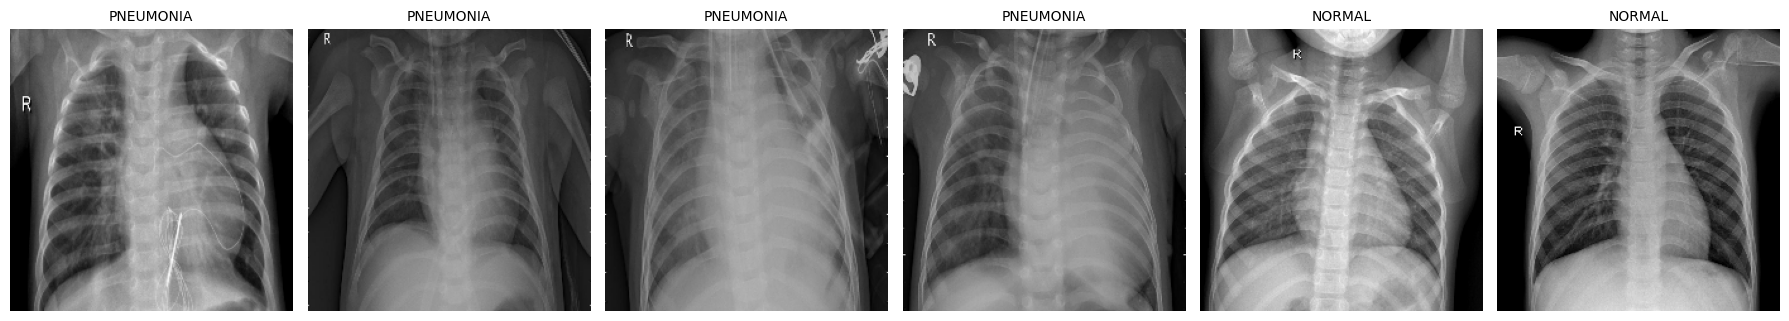

In [5]:
imgs, rotulos = next(iter(train_ds))
print('Shape do batch:', imgs.shape, '| rotulos (0=NORMAL, 1=PNEUMONIA):', rotulos[:8].numpy())

inv = {v: k for k, v in MAPA_ROTULO.items()}
fig, axes = plt.subplots(1, 6, figsize=(18, 3.2))
for ax, img, r in zip(axes, imgs[:6], rotulos[:6]):
    ax.imshow(img.numpy().astype('uint8'))
    ax.set_title(inv[int(r)], fontsize=10)
    ax.axis('off')
plt.tight_layout()
plt.show()

## 5. Arquitetura da CNN do zero

A augmentation (rotacao ~10 graus, zoom e translacao 0.1, **sem flip**) e o `Rescaling(1/255)` sao as primeiras camadas do modelo. Em seguida, 4 blocos `Conv2D(32 -> 64 -> 128 -> 128)` com `BatchNorm + ReLU + MaxPool`, depois `GlobalAveragePooling`, `Dropout(0.5)` e uma saida sigmoide. O GAP no lugar de `Flatten` reduz parametros e overfitting.

In [6]:
data_augmentation = keras.Sequential([
    layers.RandomRotation(0.03),          # ~ +-10 graus
    layers.RandomZoom(0.1),
    layers.RandomTranslation(0.1, 0.1),
], name='data_augmentation')

def construir_modelo():
    inputs = keras.Input(shape=(IMG, IMG, 3))
    x = data_augmentation(inputs)
    x = layers.Rescaling(1.0 / 255)(x)
    for filtros in [32, 64, 128, 128]:
        x = layers.Conv2D(filtros, 3, padding='same', use_bias=False)(x)
        x = layers.BatchNormalization()(x)
        x = layers.Activation('relu')(x)
        x = layers.MaxPooling2D()(x)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)
    return keras.Model(inputs, outputs, name='cnn_do_zero')

modelo = construir_modelo()
modelo.summary()

Model: "cnn_do_zero"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 128)    │       147,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴─────────────

 Total params: 242,017 (945.38 KB)

 Trainable params: 241,313 (942.63 KB)

 Non-trainable params: 704 (2.75 KB)

## 6. Compilacao e pesos de classe

O `class_weight` 'balanced' compensa os ~73% de pneumonia. Metricas: `accuracy`, `AUC`, `precision` e `recall` - o recall e o mais critico, pois um falso negativo e uma pneumonia nao detectada.

In [8]:
from sklearn.utils.class_weight import compute_class_weight

y_train = train_df.label.map(MAPA_ROTULO).values
pesos = compute_class_weight('balanced', classes=np.array([0, 1]), y=y_train)
class_weight = {0: float(pesos[0]), 1: float(pesos[1])}
print('class_weight:', class_weight)

modelo.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        keras.metrics.AUC(name='auc'),
        keras.metrics.Precision(name='precision'),
        keras.metrics.Recall(name='recall'),
    ],
)

class_weight: {0: 1.9262767710049424, 1: 0.6752815477909327}


## 7. Treinamento

Ate 30 epocas. `EarlyStopping` devolve os pesos da melhor epoca (`val_loss`); `ReduceLROnPlateau` reduz o learning rate em plato; `ModelCheckpoint` salva o melhor modelo em `cnn_zero.keras`.

In [10]:
callbacks = [
    keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6),
    keras.callbacks.ModelCheckpoint('cnn_zero.keras', monitor='val_loss', save_best_only=True),
]

historico = modelo.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    class_weight=class_weight,
    callbacks=callbacks,
)

Epoch 1/30
147/147 ━━━━━━━━━━━━━━━━━━━━ 19s 126ms/step - accuracy: 0.9329 - auc: 0.9825 - loss: 0.1665 - precision: 0.9781 - recall: 0.9301 - val_accuracy: 0.9297 - val_auc: 0.9646 - val_loss: 0.2359 - val_precision: 0.9262 - val_recall: 0.9857 - learning_rate: 5.0000e-04
Epoch 2/30
147/147 ━━━━━━━━━━━━━━━━━━━━ 18s 125ms/step - accuracy: 0.9365 - auc: 0.9825 - loss: 0.1642 - precision: 0.9800 - recall: 0.9333 - val_accuracy: 0.7568 - val_auc: 0.8699 - val_loss: 1.1104 - val_precision: 0.7568 - val_recall: 1.0000 - learning_rate: 5.0000e-04
Epoch 3/30
147/147 ━━━━━━━━━━━━━━━━━━━━ 19s 128ms/step - accuracy: 0.9410 - auc: 0.9855 - loss: 0.1521 - precision: 0.9804 - recall: 0.9391 - val_accuracy: 0.7604 - val_auc: 0.9716 - val_loss: 0.7270 - val_precision: 0.7595 - val_recall: 1.0000 - learning_rate: 5.0000e-04
Epoch 4/30
147/147 ━━━━━━━━━━━━━━━━━━━━ 19s 130ms/step - accuracy: 0.9356 - auc: 0.9832 - loss: 0.1624 - precision: 0.9797 - recall: 0.9324 - val_accuracy: 0.7712 - val_auc: 0.9090 

## 8. Curvas de treino

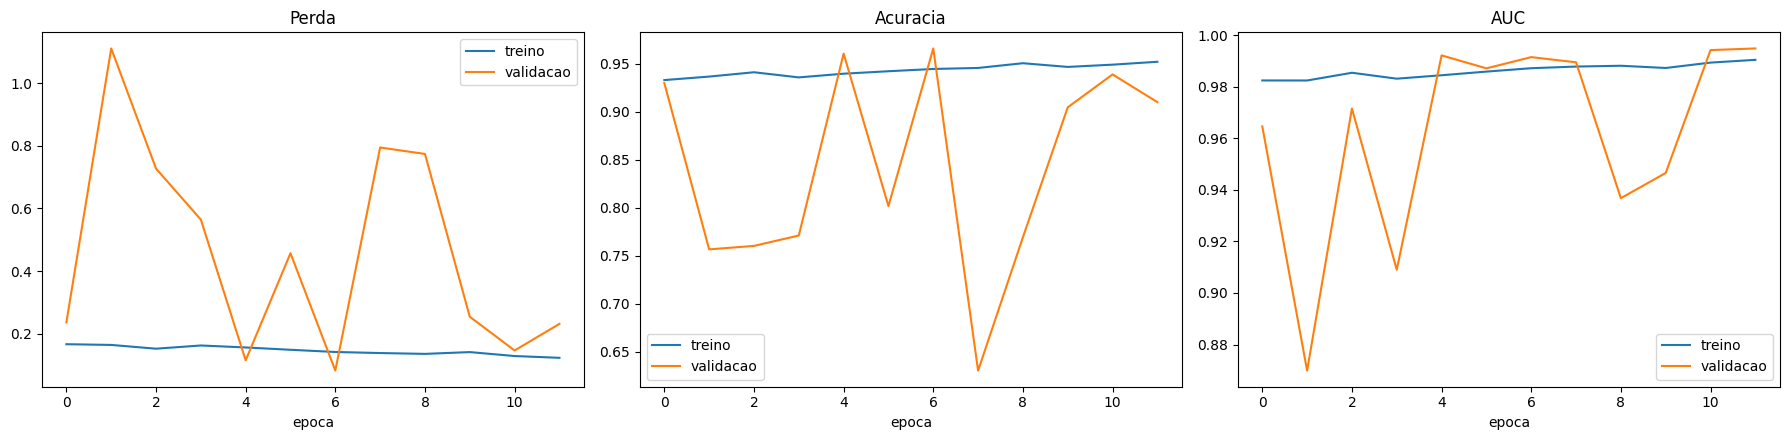

In [11]:
hist = historico.history
fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))
for ax, metrica, titulo in zip(axes, ['loss', 'accuracy', 'auc'], ['Perda', 'Acuracia', 'AUC']):
    ax.plot(hist[metrica], label='treino')
    ax.plot(hist['val_' + metrica], label='validacao')
    ax.set_title(titulo)
    ax.set_xlabel('epoca')
    ax.legend()
plt.tight_layout()
plt.savefig('cnn_zero_curvas_treino.png', dpi=120, bbox_inches='tight')
plt.show()

## 9. Avaliacao no conjunto de teste

O teste (624 imagens) ficou intocado no NB01 e no treino. Reportamos a matriz de confusao, o `classification_report` (precision/recall/F1 por classe) e a AUC-ROC. Como o `test_ds` nao embaralha, a ordem das predicoes casa com `test_df`.

In [12]:
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, roc_auc_score, RocCurveDisplay)

metricas_teste = modelo.evaluate(test_ds, return_dict=True, verbose=0)
print('Metricas no teste:', {k: round(v, 4) for k, v in metricas_teste.items()})

y_true = np.concatenate([y.numpy() for _, y in test_ds]).astype(int)
y_prob = modelo.predict(test_ds, verbose=0).ravel()
y_pred = (y_prob >= 0.5).astype(int)

print()
print(classification_report(y_true, y_pred, target_names=['NORMAL', 'PNEUMONIA'], digits=3))
print('AUC-ROC:', round(roc_auc_score(y_true, y_prob), 4))

Metricas no teste: {'accuracy': 0.7821, 'auc': 0.9237, 'loss': 0.701, 'precision': 0.7424, 'recall': 0.9974}

              precision    recall  f1-score   support

      NORMAL      0.990     0.423     0.593       234
   PNEUMONIA      0.742     0.997     0.851       390

    accuracy                          0.782       624
   macro avg      0.866     0.710     0.722       624
weighted avg      0.835     0.782     0.754       624

AUC-ROC: 0.9429


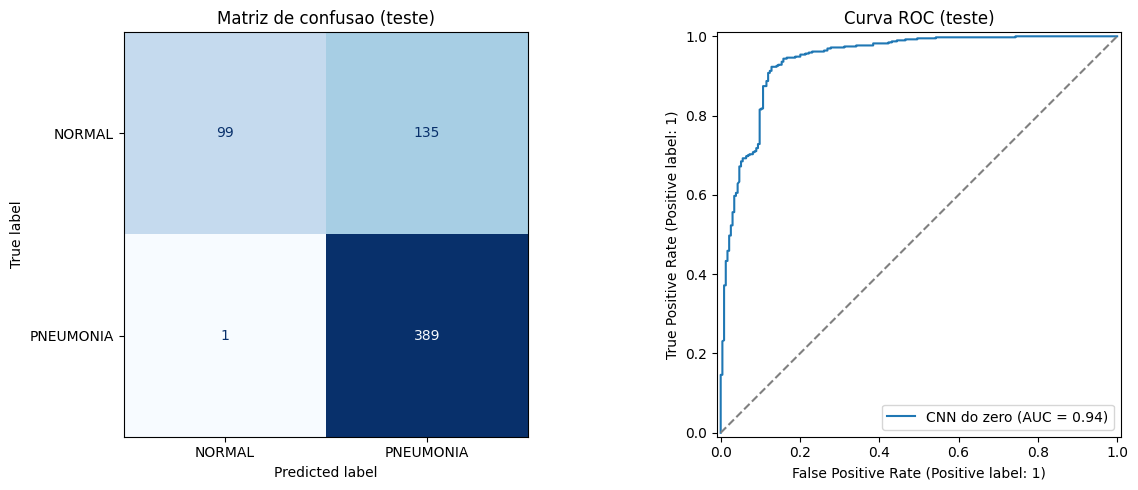

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

cm = confusion_matrix(y_true, y_pred)
ConfusionMatrixDisplay(cm, display_labels=['NORMAL', 'PNEUMONIA']).plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Matriz de confusao (teste)')

RocCurveDisplay.from_predictions(y_true, y_prob, ax=axes[1], name='CNN do zero')
axes[1].plot([0, 1], [0, 1], '--', color='gray')
axes[1].set_title('Curva ROC (teste)')

plt.tight_layout()
plt.savefig('cnn_zero_matriz_roc.png', dpi=120, bbox_inches='tight')
plt.show()

## 10. Analise de falsos negativos

Falso negativo = pneumonia classificada como NORMAL, o erro clinicamente mais grave (alta liberada para um paciente doente). Visualizamos alguns casos com a probabilidade que o modelo atribuiu.

Total de falsos negativos: 1


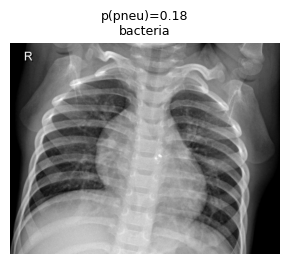

In [14]:
test_reset = test_df.reset_index(drop=True)
fn_idx = np.where((y_true == 1) & (y_pred == 0))[0]
print('Total de falsos negativos:', len(fn_idx))

n = min(6, len(fn_idx))
if n > 0:
    fig, axes = plt.subplots(1, n, figsize=(3 * n, 3.4))
    if n == 1:
        axes = [axes]
    for ax, i in zip(axes, fn_idx[:n]):
        linha = test_reset.iloc[i]
        with Image.open(DATA_ROOT / linha.filepath) as im:
            ax.imshow(im, cmap='gray')
        ax.set_title('p(pneu)=' + format(y_prob[i], '.2f') + '\n' + str(linha.subtipo), fontsize=9)
        ax.axis('off')
    plt.tight_layout()
    plt.show()
else:
    print('Nenhum falso negativo neste conjunto.')

## 11. Exportacao do modelo

Salvamos `cnn_zero.keras` (o `ModelCheckpoint` ja salvou o melhor; re-salvamos por garantia) e montamos um resumo. Este arquivo **nao vai para o git** (esta no `.gitignore`) - entregue-o ao **Pessoa 3** para anexar ao GitHub Release `v1.0-modelos`. Importante: a normalizacao (`Rescaling 1/255`) esta embutida no modelo, entao o Flask **nao** deve renormalizar a entrada da CNN.

In [16]:
modelo.save('cnn_zero.keras')
print('Modelo salvo em cnn_zero.keras')

resumo = {
    'arquitetura': 'cnn_do_zero',
    'img_size': IMG,
    'preprocess': 'rescaling_1_255_embutido',
    'classes': {'0': 'NORMAL', '1': 'PNEUMONIA'},
    'threshold': 0.5,
    'tf_version': tf.__version__,
    'teste': {k: round(float(v), 4) for k, v in metricas_teste.items()},
    'auc_roc_teste': round(float(roc_auc_score(y_true, y_prob)), 4),
}
print(json.dumps(resumo, indent=2, ensure_ascii=False))

#Baixar para anexar ao Release e salvar as evidencias:
from google.colab import files
files.download('cnn_zero.keras')
files.download('cnn_zero_curvas_treino.png')
files.download('cnn_zero_matriz_roc.png')

Modelo salvo em cnn_zero.keras
{
  "arquitetura": "cnn_do_zero",
  "img_size": 224,
  "preprocess": "rescaling_1_255_embutido",
  "classes": {
    "0": "NORMAL",
    "1": "PNEUMONIA"
  },
  "threshold": 0.5,
  "tf_version": "2.20.0",
  "teste": {
    "accuracy": 0.7821,
    "auc": 0.9237,
    "loss": 0.701,
    "precision": 0.7424,
    "recall": 0.9974
  },
  "auc_roc_teste": 0.9429
}


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 12. Conclusao e proximos passos

- A CNN do zero foi treinada e avaliada **no conjunto de teste** (precision/recall/F1 por classe + AUC-ROC), com `class_weight` para o desbalanceamento.
- `cnn_zero.keras` carrega a normalizacao embutida (`Rescaling 1/255`) - o Flask infere sem renormalizar a entrada da CNN.
- **Entregar `cnn_zero.keras` ao Pessoa 3** para anexar ao GitHub Release `v1.0-modelos`.
- O comparativo **CNN do zero x VGG16** (no mesmo conjunto de teste) e a discussao final entram em `docs/relatorio_parte2_cnn_transfer_learning.md`; a analise de vies dos modelos vai em `notebooks/04_fairness.ipynb` (Ir Alem 1).

**Antes de commitar:** rodar `Runtime > Run all` no Colab com GPU T4, salvar o notebook **com os outputs** e copiar `cnn_zero_curvas_treino.png` e `cnn_zero_matriz_roc.png` para `assets/evidencias/`.